

1.   Outliers
2.   Visualization


> Post Winsorization

1.   outliers check: should be gone
2.   visualization







In [7]:
# Import required libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats.mstats import winsorize

In [8]:
df = pd.read_csv('HousePrices.csv')
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


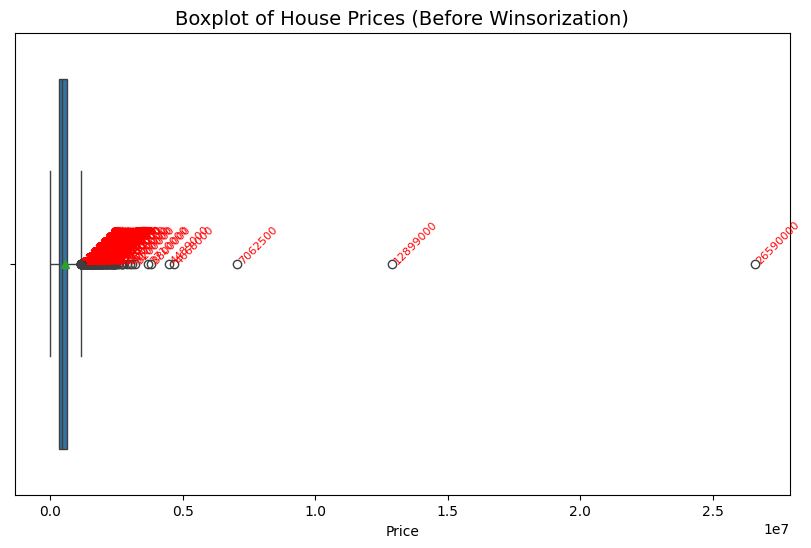

Number of outliers detected: 240


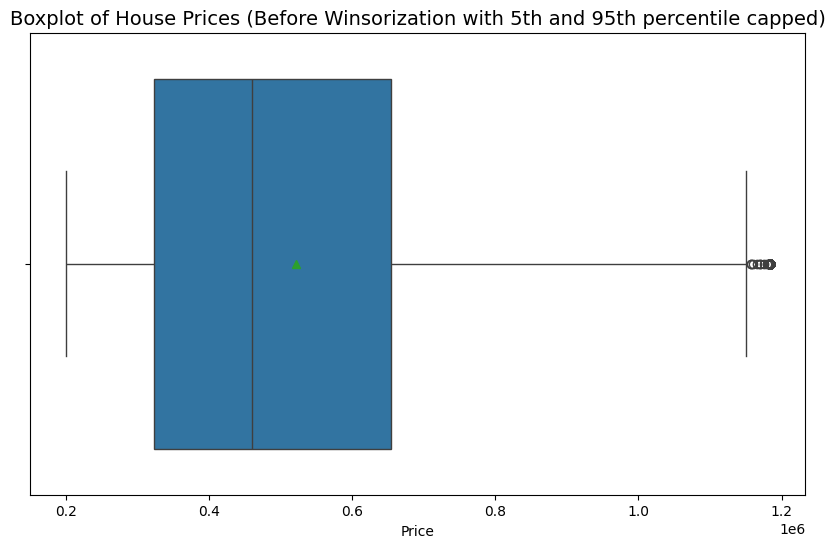

In [11]:
# Visualize outliers using Boxplot
plt.figure(figsize=(10,6))
sns.boxplot(x=df['price'], showmeans=True)
plt.title('Boxplot of House Prices (Before Winsorization)', fontsize=14)
plt.xlabel('Price')

q1 = df['price'].quantile(0.25)
q3 = df['price'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]

for i, val in enumerate(outliers['price']):
    plt.text(val, 0, f'{val:.0f}', rotation=45, fontsize=8, color='red')

plt.show()
print('Number of outliers detected:', len(outliers))

# Visualize outliers using Boxplot with values capped at 5th and 95th percentile
plt.figure(figsize=(10,6))
sns.boxplot(x=df['price'].clip(lower=df['price'].quantile(0.05), upper=df['price'].quantile(0.95)), showmeans=True)
plt.title('Boxplot of House Prices (Before Winsorization with 5th and 95th percentile capped)', fontsize=14)
plt.xlabel('Price')
plt.show()

In [12]:
display(outliers['price'])

,price
1,2.384000e+06
11,1.400000e+06
14,1.200000e+06
99,1.395000e+06
122,2.280000e+06
...,...
4348,2.199900e+06
4350,2.659000e+07
4465,2.560498e+06
4467,1.337044e+06


In [15]:
df['price_winsorized'] = winsorize(df['price'], limits=(0.05, 0.05))
display(df[['price', 'price_winsorized']].head())

,price,price_winsorized
0,313000.0,313000.0
1,2384000.0,1184000.0
2,342000.0,342000.0
3,420000.0,420000.0
4,550000.0,550000.0


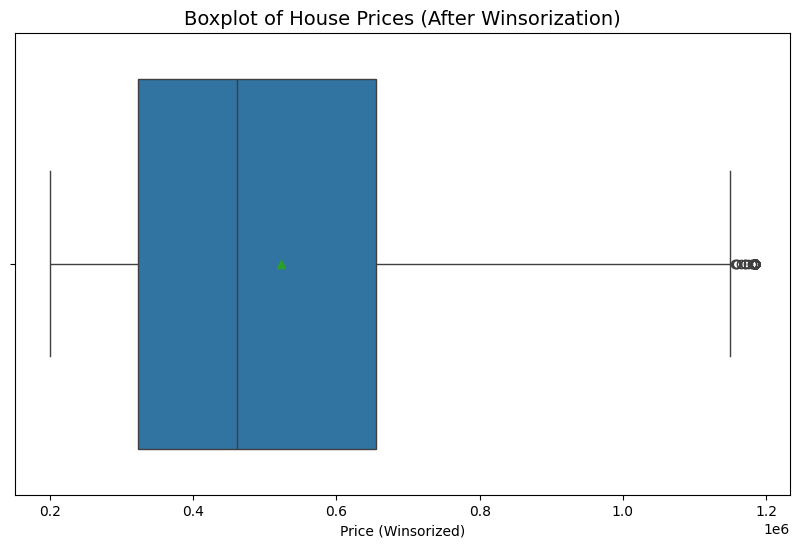

In [16]:
plt.figure(figsize=(10,6))
sns.boxplot(x=df['price_winsorized'], showmeans=True)
plt.title('Boxplot of House Prices (After Winsorization)', fontsize=14)
plt.xlabel('Price (Winsorized)')
plt.show()